# Results of the study

All events, all issue times, pooled (`results/report.md` has every table). Run
`python projects/nowcasting/pysteps/src/run.py study --network <name>` for each network, then
`run.py report`.

In [1]:
import sys
import warnings
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from core import viz_style as vs
from os_nowcasting import report
vs.use_style()

In [2]:
tabs = report.load()
det, ens, mot = (report._cat(tabs, k) for k in ("deterministic", "ensemble", "motion"))
{n: (t["issues"].event.nunique(), len(t["issues"])) for n, t in tabs.items()}

Pysteps configuration file found at: /Users/drorjac/.pysteps/pystepsrc



{'openrainer': (4, 143), 'openmrg': (5, 128)}

In [3]:
from IPython.display import Markdown
out = []
for n in tabs:
    out += [f"### {report.NAMES[n]}", "radar, all methods (LINDA subset)", report.table_radar_methods(det, n, "radar (LINDA subset)"),
            "every product, extrapolation, 60 min", report.table_products(det, n),
            "STEPS", report.table_ensemble(ens, n), "motion methods", report.table_motion(mot, n)]
Markdown("\n\n".join(out))

### OpenRainER (Emilia-Romagna, 15 min)

radar, all methods (LINDA subset)

| method | CSI 1 mm/h, 30 min | 60 min | 90 min | FSS 10 km, 60 min | MAE 60 min (mm/h) | corr 60 min | gauges: corr 60 min | gauges: RMSE 60 min | forecasts |
|---|---|---|---|---|---|---|---|---|---|
| persistence | 0.42 | 0.30 | 0.22 | 0.55 | 1.12 | 0.22 | 0.14 | 4.99 | 49 |
| extrapolation | 0.57 | 0.42 | 0.32 | 0.71 | 0.91 | 0.37 | 0.26 | 4.32 | 49 |
| sprog | 0.61 | 0.47 | 0.36 | 0.73 | 0.91 | 0.39 | 0.26 | 4.55 | 49 |
| anvil | 0.52 | 0.40 | 0.30 | 0.68 | 0.93 | 0.36 | 0.28 | 4.34 | 49 |
| linda | 0.59 | 0.47 | 0.38 | 0.72 | 1.00 | 0.47 | 0.36 | 4.25 | 49 |

every product, extrapolation, 60 min

| product | own: CSI 1 | own: CSI 1, persistence | own: FSS 10 km | radar: CSI 1 | radar: FSS 10 km | radar: MAE | gauges: corr | gauges: RMSE | gauges: ME |
|---|---|---|---|---|---|---|---|---|---|
| radar | 0.40 | 0.27 | 0.68 | 0.40 | 0.68 | 0.92 | 0.25 | 4.42 | 0.30 |
| merged | 0.26 | 0.19 | 0.51 | 0.30 | 0.56 | 0.94 | 0.22 | 4.36 | 0.11 |
| cml_idw40 | 0.16 | 0.17 | 0.30 | 0.13 | 0.27 | 0.89 | 0.15 | 4.19 | -0.14 |
| cml_idw20 | 0.16 | 0.17 | 0.31 | 0.07 | 0.15 | 0.83 | 0.08 | 4.19 | -0.25 |
| cml_idw10 | 0.14 | 0.16 | 0.28 | 0.03 | 0.06 | 0.80 | 0.05 | 4.04 | -0.41 |

STEPS

| product | ensemble | CRPS 30 min (mm/h) | CRPS 60 min | ROC area 1 mm/h, 60 min | ens. mean CSI 1, 60 min | gauges: CRPS 60 min | forecasts |
|---|---|---|---|---|---|---|---|
| radar | steps | 0.48 | 0.63 | 0.86 | 0.44 | 0.71 | 143 |
| radar | linda_p | 0.43 | 0.59 | 0.88 | 0.44 | 0.63 | 26 |
| merged | steps | 0.57 | 0.66 | 0.80 | 0.35 | 0.60 | 143 |
| cml_idw40 | steps | 0.77 | 0.78 | 0.60 | 0.15 | 0.66 | 143 |
| cml_idw20 | steps | 0.77 | 0.78 | 0.55 | 0.08 | 0.64 | 143 |
| cml_idw10 | steps | 0.78 | 0.78 | 0.52 | 0.03 | 0.61 | 143 |
| radar (LINDA-P subset) | steps | 0.43 | 0.60 | 0.85 | 0.44 | 0.61 | 26 |
| radar (LINDA-P subset) | linda_p | 0.43 | 0.59 | 0.88 | 0.44 | 0.63 | 26 |

motion methods

| motion | CSI 1, 30 min | 60 min | 90 min | MAE 60 min | FSS 10 km, 60 min |
|---|---|---|---|---|---|
| LK | 0.56 | 0.40 | 0.30 | 0.95 | 0.68 |
| LK (no dB) | 0.55 | 0.39 | 0.30 | 0.96 | 0.67 |
| VET | 0.57 | 0.41 | 0.30 | 0.96 | 0.69 |
| DARTS | 0.46 | 0.30 | 0.22 | 1.10 | 0.56 |
| proesmans | 0.57 | 0.40 | 0.30 | 0.98 | 0.69 |

### OpenMRG (Gothenburg, 5 min)

radar, all methods (LINDA subset)

| method | CSI 1 mm/h, 30 min | 60 min | 90 min | FSS 10 km, 60 min | MAE 60 min (mm/h) | corr 60 min | gauges: corr 60 min | gauges: RMSE 60 min | forecasts |
|---|---|---|---|---|---|---|---|---|---|
| persistence | 0.30 | 0.21 | 0.14 | 0.53 | 1.03 | 0.16 | 0.10 | 3.24 | 39 |
| extrapolation | 0.47 | 0.37 | 0.17 | 0.78 | 0.75 | 0.42 | 0.05 | 2.77 | 39 |
| sprog | 0.51 | 0.40 | 0.20 | 0.78 | 0.86 | 0.43 | 0.11 | 2.65 | 39 |
| anvil | 0.35 | 0.24 | 0.19 | 0.59 | 0.96 | 0.20 | 0.05 | 2.95 | 39 |
| linda | 0.49 | 0.41 | 0.27 | 0.73 | 1.74 | 0.42 | 0.10 | 3.47 | 39 |

every product, extrapolation, 60 min

| product | own: CSI 1 | own: CSI 1, persistence | own: FSS 10 km | radar: CSI 1 | radar: FSS 10 km | radar: MAE | gauges: corr | gauges: RMSE | gauges: ME |
|---|---|---|---|---|---|---|---|---|---|
| radar | 0.33 | 0.21 | 0.71 | 0.33 | 0.71 | 0.76 | 0.07 | 2.88 | -0.10 |
| merged | 0.19 | 0.16 | 0.45 | 0.20 | 0.48 | 0.95 | 0.14 | 2.80 | 0.05 |
| cml_idw40 | 0.22 | 0.21 | 0.42 | 0.19 | 0.42 | 1.00 | 0.17 | 2.96 | 0.03 |
| cml_idw20 | 0.21 | 0.20 | 0.40 | 0.18 | 0.40 | 1.05 | 0.09 | 3.73 | 0.23 |
| cml_idw10 | 0.20 | 0.20 | 0.40 | 0.15 | 0.36 | 0.99 | 0.14 | 2.96 | -0.03 |
| pws_idw | 0.29 | 0.30 | 0.52 | 0.26 | 0.51 | 1.24 | 0.15 | 2.72 | -0.11 |

STEPS

| product | ensemble | CRPS 30 min (mm/h) | CRPS 60 min | ROC area 1 mm/h, 60 min | ens. mean CSI 1, 60 min | gauges: CRPS 60 min | forecasts |
|---|---|---|---|---|---|---|---|
| radar | steps | 0.50 | 0.52 | 0.78 | 0.34 | 0.59 | 111 |
| radar | linda_p | 0.55 | 0.65 | 0.83 | 0.44 | 0.75 | 22 |
| merged | steps | 0.64 | 0.64 | 0.65 | 0.21 | 0.68 | 120 |
| cml_idw40 | steps | 0.74 | 0.71 | 0.63 | 0.19 | 0.89 | 63 |
| cml_idw20 | steps | 0.67 | 0.67 | 0.65 | 0.22 | 0.92 | 66 |
| cml_idw10 | steps | 0.83 | 0.77 | 0.64 | 0.21 | 0.87 | 61 |
| pws_idw | steps | 0.78 | 0.92 | 0.68 | 0.27 | 0.90 | 101 |
| radar (LINDA-P subset) | steps | 0.46 | 0.52 | 0.81 | 0.39 | 0.35 | 22 |
| radar (LINDA-P subset) | linda_p | 0.55 | 0.65 | 0.83 | 0.44 | 0.75 | 22 |

motion methods

| motion | CSI 1, 30 min | 60 min | 90 min | MAE 60 min | FSS 10 km, 60 min |
|---|---|---|---|---|---|
| LK | 0.48 | 0.34 | 0.20 | 0.78 | 0.74 |
| LK (no dB) | 0.47 | 0.33 | 0.18 | 0.79 | 0.73 |
| VET | 0.45 | 0.31 | 0.17 | 0.84 | 0.70 |
| DARTS | 0.36 | 0.28 | 0.14 | 0.90 | 0.64 |
| proesmans | 0.46 | 0.33 | 0.18 | 0.84 | 0.72 |

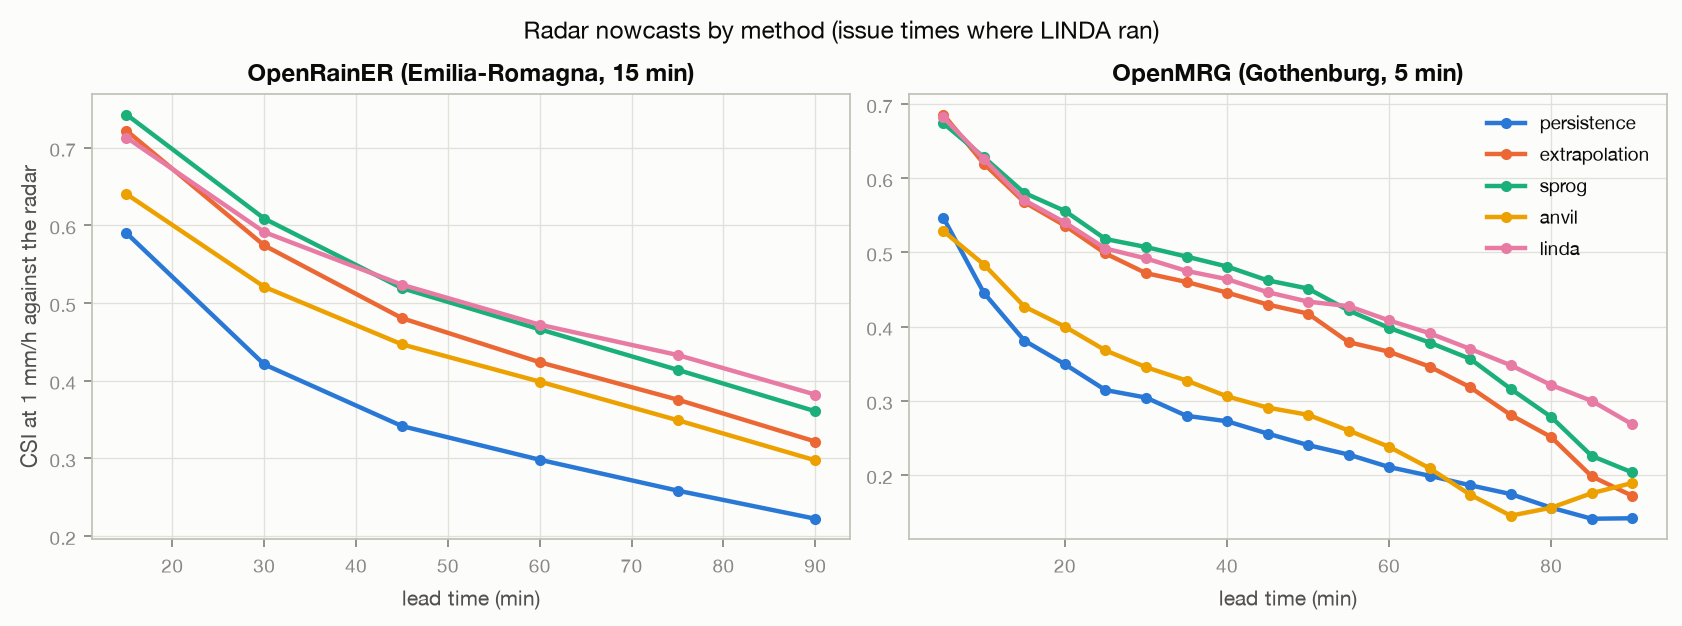

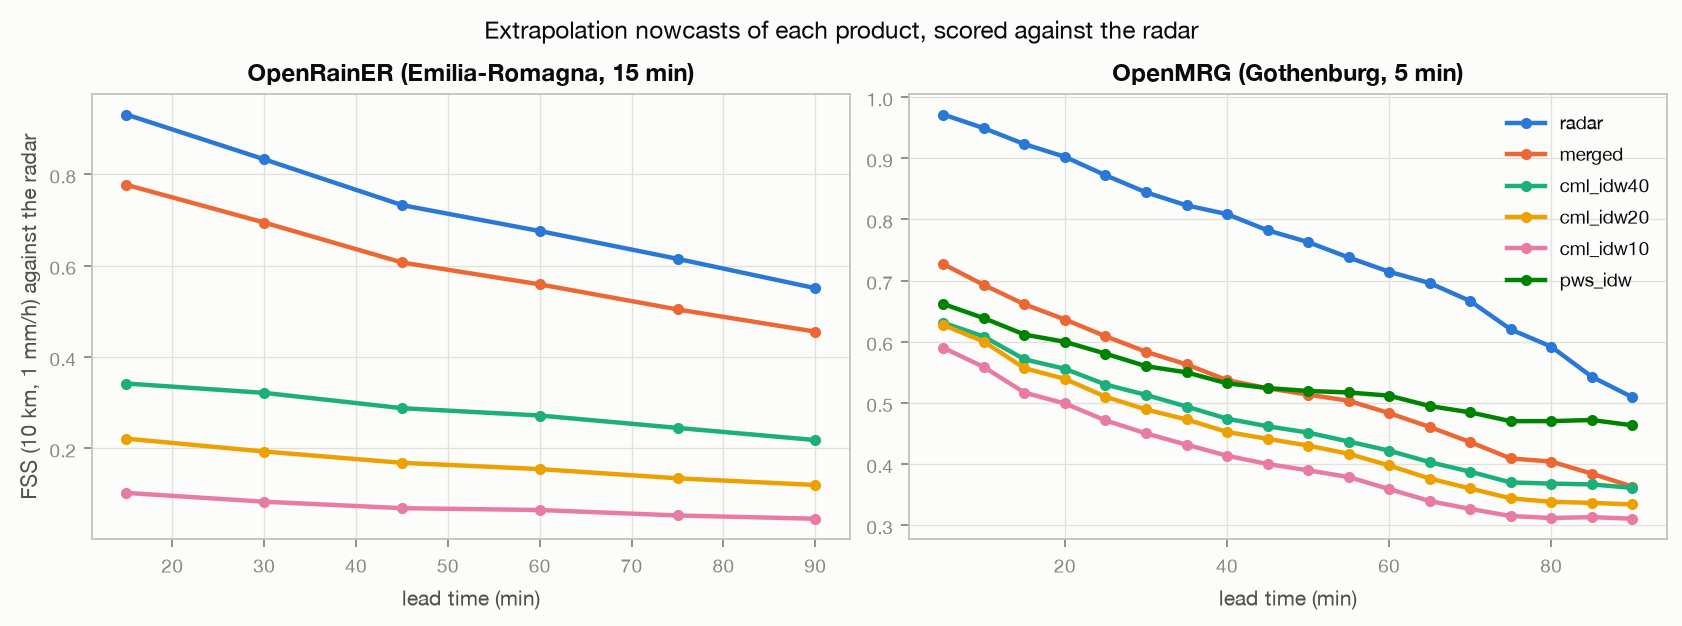

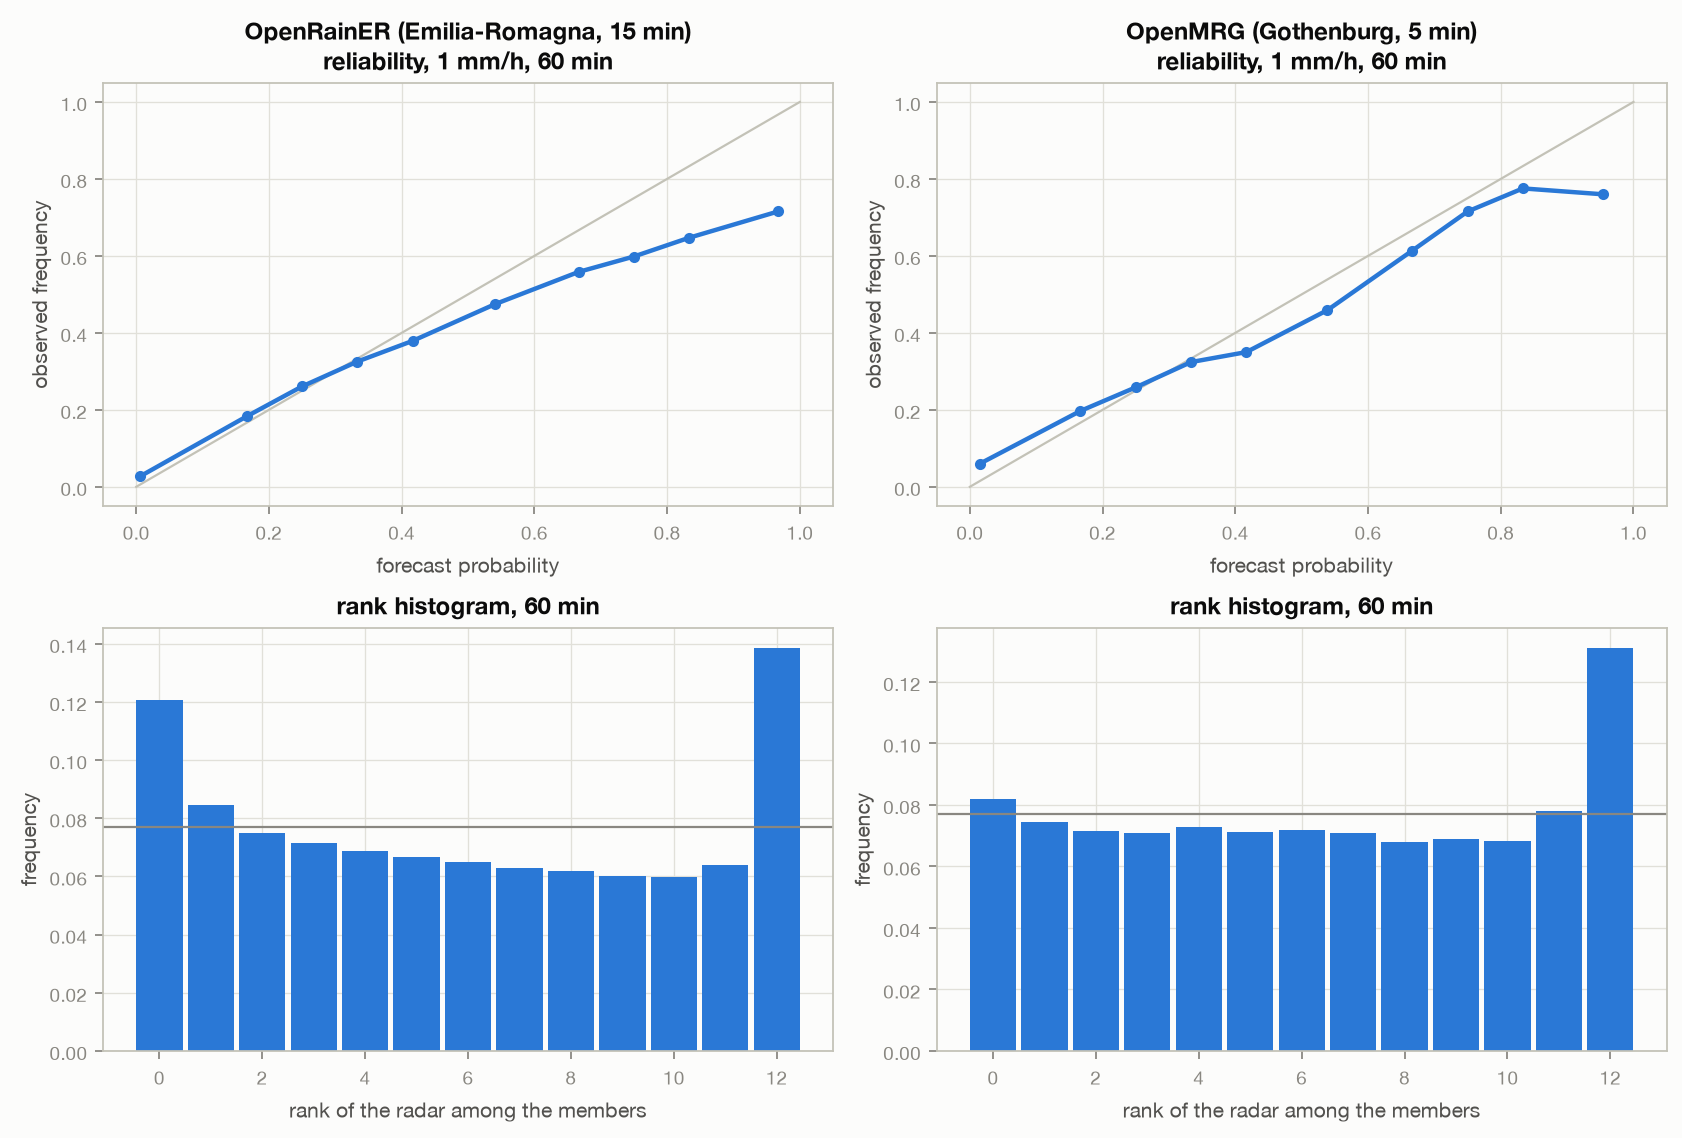

In [4]:
from IPython.display import Image, display
for f in sorted(Path("../results/figures").glob("*.png")):
    display(Image(str(f)))